In [21]:
# ==============================================================================
# STATISTICAL DATA ANALYSIS & DISTRIBUTION MODELING
# A comprehensive pipeline for descriptive statistics, calculating k-th order 
# moments, empirical cumulative distribution functions (ECDF) via symbolic math 
# (SymPy), and transitioning from discrete to continuous (interval) distributions.
# ==============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sympy
from tabulate import tabulate
from statsmodels.distributions.empirical_distribution import ECDF

# ==============================================================================
# PHASE 1: DATA GENERATION & DISCRETE DISTRIBUTION SETUP
# ==============================================================================

# Initialize dataset parameters
AMOUNT = 50
START, END, SIZE = 10, 30, 32

# Generate and sort random sample
sample = np.random.randint(START, END, SIZE)
sample.sort()

print(f"[*] Sorted Sample ({len(sample)} elements):")
for i in range(len(sample)):
    end_char = "\n" if (i + 1) % 10 == 0 else "\t"
    print(f"{sample[i]}", end=end_char)
print("\n")

def get_stat_distribution(arr, df):
    """Calculates absolute frequencies for discrete distribution."""
    stat_dist = {}
    for i in arr:
        stat_dist[i] = stat_dist.get(i, 0) + 1
    df["x_i"] = list(stat_dist.keys())
    df["n_i"] = list(stat_dist.values())
    return df

def get_stat_frequency(df, n):
    """Calculates relative frequencies."""
    df["w_i"] = df["n_i"] / n
    return df

# Build Discrete DataFrame
df_discrete = pd.DataFrame()
df_discrete = get_stat_distribution(sample, df_discrete)
df_discrete = get_stat_frequency(df_discrete, len(sample))

Sample :  [18 24 26 10 19 25 24 18 27 12 25 10 28 10 29 11 23 28 20 12 28 17 19 17
 24 13 18 24 17 12 29 15]
Variantial row: 
10	10	10	11	12	12	12	13	15	17	
17	17	18	18	18	19	19	20	23	24	
24	24	24	25	25	26	27	28	28	28	
29	29	

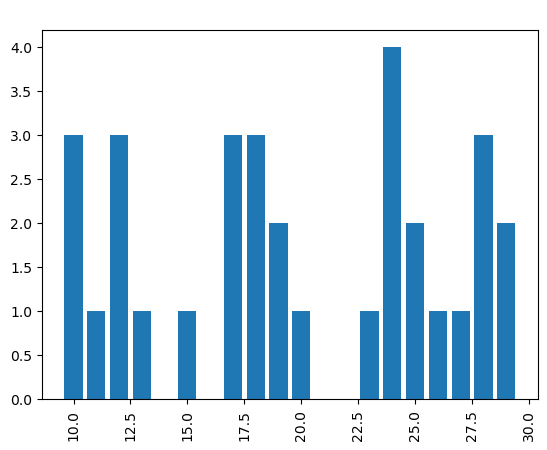

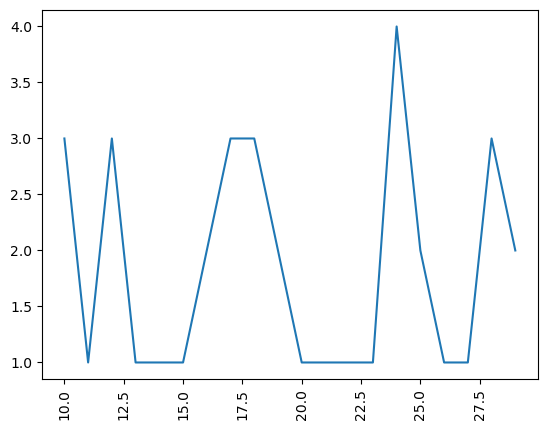

[10 10 10 11 12 12 12 13 15 17 17 17 18 18 18 19 19 20 23 24 24 24 24 25
 25 26 27 28 28 28 29 29]


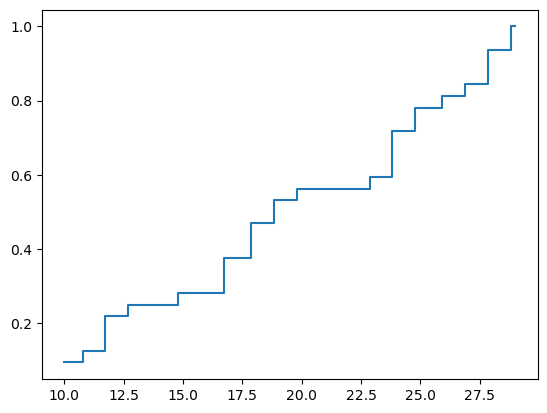

In [23]:
# ==============================================================================
# PHASE 2: DISCRETE VISUALIZATIONS
# ==============================================================================

def show_frequency_diagram(df, column="x_i"):
    plt.figure(figsize=(8, 4))
    plt.bar(df[column], df["n_i"], color='skyblue', edgecolor='black')
    plt.title("Discrete Frequency Bar Chart")
    plt.xlabel("Variants (x_i)")
    plt.ylabel("Frequencies (n_i)")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.7)
    plt.show()

def show_frequency_polygon(df, column="x_i"):
    plt.figure(figsize=(8, 4))
    plt.plot(df[column], df["n_i"], marker='o', color='red', linestyle='-')
    plt.title("Frequency Polygon")
    plt.xlabel("Variants (x_i)")
    plt.ylabel("Frequencies (n_i)")
    plt.grid(True, alpha=0.7)
    plt.show()

def show_empirical_function(arr):
    """Calculates and plots ECDF using statsmodels for exact step logic."""
    ecdf = ECDF(arr)
    plt.figure(figsize=(8, 4))
    plt.step(ecdf.x, ecdf.y, where='post', color='green', lw=2)
    plt.title("Empirical Cumulative Distribution Function (ECDF)")
    plt.xlabel("x")
    plt.ylabel("F*(x)")
    plt.grid(True, alpha=0.7)
    plt.show()

show_frequency_diagram(df_discrete)
show_frequency_polygon(df_discrete)
show_empirical_function(sample)

In [27]:
# ==============================================================================
# PHASE 3: DISCRETE NUMERICAL CHARACTERISTICS & MOMENTS
# ==============================================================================

def get_deviation(df, average):
    return sum(df['n_i'] * (df['x_i'] - average) ** 2)

def central_moment_s_degree(df, average, n, s, column="x_i"):
    """Calculates k-th order central moment."""
    return sum(df['n_i'] * (df[column] - average) ** s) / n

def print_quantiles(arr, count_quant, label):
    """Calculates and prints positional quantiles."""
    indexes = np.linspace(0, len(arr), num=count_quant + 1)[1:-1]
    indexes = [int(i) for i in indexes]
    
    print(f"\n[*] {label}:")
    temp = 0
    for k, i in enumerate(indexes, 1):
        val = arr[i - 1]
        print(f"  {label[0].upper()}{k} = {val}")
        temp = val
    if len(indexes) > 0:
        print(f"  Interquantile Range: {temp - arr[indexes[0]]}")

average_d = sum(sample) / len(sample)
modes_d = df_discrete[df_discrete['n_i'] == df_discrete['n_i'].max()]['x_i'].tolist()
median_d = sample[len(sample)//2] if len(sample) % 2 != 0 else (sample[len(sample)//2 - 1] + sample[len(sample)//2]) / 2

print("\n" + "="*50)
print(" DISCRETE DISTRIBUTION METRICS")
print("="*50)
print(f"Arithmetic Mean: {average_d:.4f}")
print(f"Mode(s): {modes_d}")
print(f"Median: {median_d}")

dev_d = get_deviation(df_discrete, average_d)
variance_d = dev_d / (len(sample) - 1)  # Unbiased sample variance
std_dev_d = math.sqrt(variance_d)

print(f"\nDeviation (Sum of Squares): {dev_d:.4f}")
print(f"Sample Variance (s^2): {variance_d:.4f}")
print(f"Standard Deviation (s): {std_dev_d:.4f}")
print(f"Range: {max(sample) - min(sample)}")
print(f"Coefficient of Variation: {std_dev_d / average_d:.4f}")

# Moments calculation
m2 = central_moment_s_degree(df_discrete, average_d, len(sample), 2)
m3 = central_moment_s_degree(df_discrete, average_d, len(sample), 3)
m4 = central_moment_s_degree(df_discrete, average_d, len(sample), 4)

print(f"\nAsymmetry (Skewness): {m3 / (m2 ** 1.5):.4f}")
print(f"Kurtosis (Excess): {(m4 / (m2 ** 2)) - 3:.4f}")

print_quantiles(sample, 4, "Quartiles")


	Числові характеристики: 
Середнє арифметичне: 19.75
Мода: 24
Медіана: 19.0

Девіація: 1248.0
Варіанса: 40.25806451612903
Стандарта: 6.3449243113002565
Розмах: 19
Варіація: 0.3212619904455826
Дисперсія: 39.0

Середньо квадратичне відхилення: 6.244997998398398

Введіть к-сть центральних моментів, які треба порахувати: 4
Центральні моменти:
Центральний момент 2-го порядку: 39.0
Центральний момент 3-го порядку: -25.546875
Центральний момент 4-го порядку: 2573.26171875

Початкові моменти:
Початковий момент 2-го порядку: 429.0625
Початковий момент 3-го порядку: 9988.9375
Початковий момент 4-го порядку: 243978.4375


Квантилі: 
Q1 = 13
Q2 = 19
Q3 = 25

Інтерквартильна широта :  10

Октилі: 
O1 = 11
O2 = 13
O3 = 17
O4 = 19
O5 = 24
O6 = 25
O7 = 28

Інтерквартильна широта :  16

Асиметрія: -0.10489163921126501
Ексцес: -1.308177699704142




Інтервальний (неперервний) ститистичний розподіл


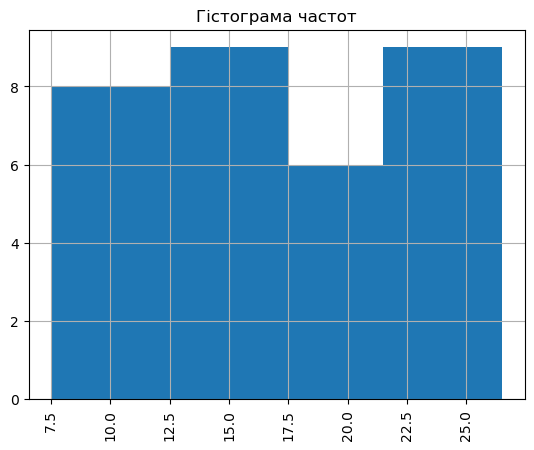

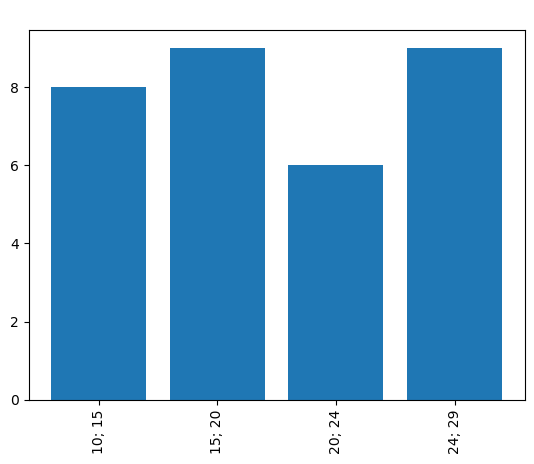

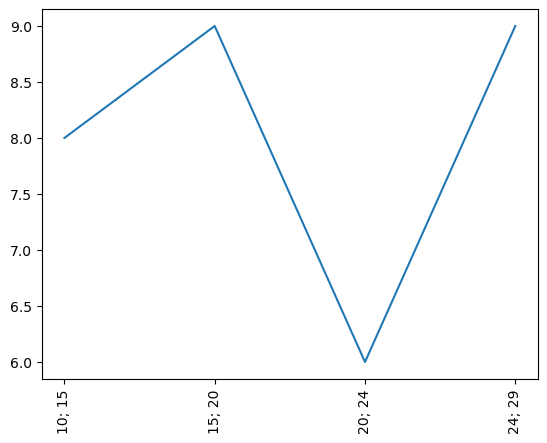

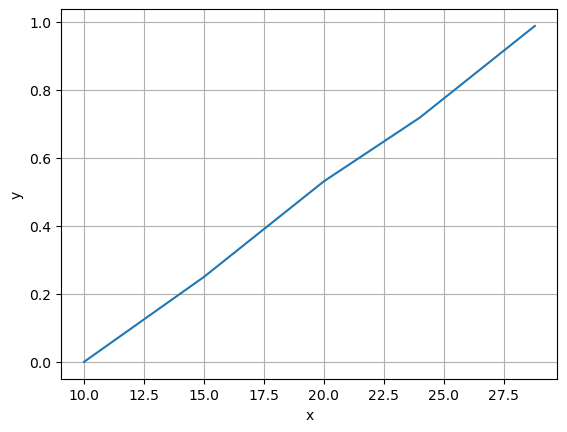

In [28]:
# ==============================================================================
# PHASE 4: CONTINUOUS (INTERVAL) DISTRIBUTION SETUP
# ==============================================================================

def get_stat_distribution_interval(arr, class_length):
    stat_dist = {}
    for i in np.arange(arr[0], arr[-1], class_length):
        start, end = round(i, 2), round(i + class_length, 2)
        key = f"{start}; {end}"
        # Count items within interval boundaries
        count = len([j for j in arr if start < j <= end])
        if i == arr[0]:
            count += len([j for j in arr if j == start]) # Include absolute minimum
        stat_dist[key] = count
                
    df = pd.DataFrame()
    df["h_i"] = stat_dist.keys()
    df["n_i"] = stat_dist.values()
    df["w_i"] = df["n_i"] / len(arr)
    df["start_i"] = [float(k.split("; ")[0]) for k in stat_dist.keys()]
    df["end_i"] = [float(k.split("; ")[1]) for k in stat_dist.keys()]
    df["z_i"] = (df["start_i"] + df["end_i"]) / 2
    return df

def show_empirical_function_symbolic(df):
    """Builds a piecewise linear ECDF using SymPy symbolic mathematics."""
    x_arr, y_arr = [], []
    h = 0.1
    x = sympy.Symbol("x")
    
    for i in range(len(df)):
        start, end, w = df.loc[i, "start_i"], df.loc[i, "end_i"], df.loc[i, "w_i"]
        prev_w_sum = sum(df["w_i"][:i])
        
        # Linear interpolation function for the current interval
        func = (w / (end - start)) * (x - start) + prev_w_sum
        
        value = start
        while value + h <= end:
            x_arr.append(value)
            y_arr.append(float(func.evalf(subs={x: value})))
            value += h
            
    plt.figure(figsize=(8, 4))
    plt.plot(x_arr, y_arr, color='purple', lw=2)
    plt.title("Symbolic Piecewise Continuous ECDF")
    plt.xlabel("x")
    plt.ylabel("F*(x)")
    plt.grid(True, alpha=0.7)
    plt.show()

# Apply Sturges' Rule for optimal number of bins
r = 0
while len(sample) > 2**(r + 1):
    r += 1
class_length = (max(sample) - min(sample)) / r

df_interval = get_stat_distribution_interval(sample, class_length)

print("\n" + "="*50)
print(" CONTINUOUS (INTERVAL) STATISTICAL DISTRIBUTION")
print("="*50)
print(tabulate(df_interval, headers='keys', tablefmt="pretty"))

show_frequency_diagram(df_interval, column="h_i")
show_empirical_function_symbolic(df_interval)

In [18]:
# ==============================================================================
# PHASE 5: CONTINUOUS NUMERICAL CHARACTERISTICS
# ==============================================================================

average_c = (df_interval['z_i'] * df_interval['n_i']).sum() / len(sample)

# Safe Mode Calculation for intervals
n_i = df_interval["n_i"].tolist()
start_i = df_interval["start_i"].tolist()
end_i = df_interval["end_i"].tolist()

idx_max = np.argmax(n_i)
n_m = n_i[idx_max]
n_prev = n_i[idx_max - 1] if idx_max > 0 else 0
n_next = n_i[idx_max + 1] if idx_max < len(n_i) - 1 else 0

mode_c = start_i[idx_max] + ((n_m - n_prev) / (2 * n_m - n_prev - n_next)) * (end_i[idx_max] - start_i[idx_max])

# Safe Median Calculation for intervals
cum_freq = 0
med_idx = 0
for i, freq in enumerate(n_i):
    cum_freq += freq
    if cum_freq >= len(sample) / 2:
        med_idx = i
        break
        
prev_cum_freq = sum(n_i[:med_idx])
median_c = start_i[med_idx] + ((len(sample) / 2 - prev_cum_freq) / n_i[med_idx]) * (end_i[med_idx] - start_i[med_idx])

print(f"\n[*] Continuous Metrics:")
print(f"Mean (Grouped): {average_c:.4f}")
print(f"Mode (Grouped): {mode_c:.4f}")
print(f"Median (Grouped): {median_c:.4f}")

dev_c = (df_interval['n_i'] * (df_interval['z_i'] - average_c)**2).sum()
variance_c = dev_c / (len(sample) - 1)
std_dev_c = math.sqrt(variance_c)

print(f"\nVariance (s^2): {variance_c:.4f}")
print(f"Standard Deviation (s): {std_dev_c:.4f}")
print(f"Coefficient of Variation: {std_dev_c / average_c:.4f}")

# Reconstruct array for quantile evaluation based on interval centers (z_i)
arr_reconstructed = []
for idx, row in df_interval.iterrows():
    arr_reconstructed.extend([row['z_i']] * int(row['n_i']))

print_quantiles(sorted(arr_reconstructed), 4, "Continuous Quartiles")

m2_c = central_moment_s_degree(df_interval, average_c, len(sample), 2, column="z_i")
m3_c = central_moment_s_degree(df_interval, average_c, len(sample), 3, column="z_i")
m4_c = central_moment_s_degree(df_interval, average_c, len(sample), 4, column="z_i")

print(f"\nAsymmetry (Skewness): {m3_c / (m2_c ** 1.5):.4f}")
print(f"Kurtosis (Excess): {(m4_c / (m2_c ** 2)) - 3:.4f}")

Числові характеристики для неперевного статистичного розподілу: 
Середнє арифметичне: 4.64
Мода: 3.2
Медіана 3.9285714285714284
Девіація: 227.51999999999998
Варіанса: 4.643265306122449
Стандарт: 2.154823729710263
Розмах: 8
Варіація:  0.46440166588583254
Дисперсія: 4.5504

Середньо квадратичне відхилення: 2.1331666601557413

Введіть к-сть центральних моментів, які треба порахувати: 4
Центральні моменти:
Центральний момент 2-го порядку: 4.5504
Центральний момент 3-го порядку: 2.531088000000003
Центральний момент 4-го порядку: 34.919579520000006

Початкові моменти:
Початковий момент 2-го порядку: 26.08
Початковий момент 3-го порядку: 165.77
Початковий момент 4-го порядку: 1133.23


Асиметрія: 0.26075514286098034
Ексцес: -1.3135640322063766
